# Project Name - DataPilot AI: Industry-Specific LLM Bot for Business Intelligence and Data Engineering


# Project Summary

DataPilot AI is an industry-specific conversational LLM bot for **Technology and Information Technology (IT)**, focused on Business Intelligence and Data Engineering. The bot answers questions about SQL, cloud warehousing, pipeline orchestration, analytics engineering, and BI platforms, using a Hugging Face instruction-tuned model rather than a generic closed chatbot.

The system combines two adaptation methods. First, **retrieval-augmented generation (RAG)** grounds answers in a curated BI Knowledge Hub built from official documentation (PostgreSQL, Amazon Redshift, Microsoft Power BI, Apache Superset, Apache Airflow, and dbt). Second, **parameter-efficient fine-tuning (LoRA)** adapts `Qwen/Qwen2.5-1.5B-Instruct` on 667 domain instruction examples. Training ran on **Google Colab Tesla T4** for **3 epochs** (under the 25-epoch cap). Four-bit QLoRA was planned; the executed run used **LoRA in fp16** because bitsandbytes had no working CUDA 12.8 wheel on that Colab image.

Three data assets are kept separate: Dataset A (RAG corpus: 42 collected pages, 37 accepted documents, 281 chunks), Dataset B (fine-tuning instructions), and Dataset C (100 held-out evaluation questions). The bot is a Streamlit chat application with Fine-tuned+RAG, RAG-only, and Retrieve-only modes. It cites source URLs, refuses selected out-of-domain queries, and does not execute SQL against a warehouse.

This notebook is the **capstone submission notebook**. It documents industry selection, data, model choice, training artefacts, bot query handling, and tests. GPU training lives in `notebooks/04_qlora_finetune.ipynb`; the live Streamlit interaction required for the video is launched with `python scripts/run_app.py`.

**GitHub Link - https://github.com/Yogesh-46/industryGPT-Specialized-LLM-Bot-Using-Pre-Trained-Models**




## Problem Statement

BI developers, data engineers, and analysts work across fragmented vendor documentation: PostgreSQL SQL, Redshift physical design, Airflow scheduling, dbt tests, Power BI modelling, and Superset dashboards. A generic chatbot is fluent but often invents dialect syntax, product behaviour, or citations. That is unsafe in an industry setting where a wrong DISTKEY rule or a fake DAX function wastes engineering time.

An industry-specific bot must stay inside the chosen domain, prefer attributable documentation, and still run on academic hardware (Colab T4). DataPilot AI addresses that gap with a retrieve-then-generate chatbot: facts live in official pages; the small open-source LLM learns how to use them and how to answer in an instruction style. Version 1 is deliberately non-agentic — no live warehouse credentials and no multi-agent tool loops — so the capstone stays feasible, testable, and honest.


## Specific Objectives

1. **Industry selection:** Choose Technology and IT, scoped to Business Intelligence and Data Engineering (the brief’s examples include coding assistance, tech support, and automated documentation).
2. **Data collection:** Gather industry-specific text from curated official documentation URLs (not indiscriminate site-wide scraping), plus a separate instruction set and a held-out test set.
3. **Data quality:** Clean HTML, remove boilerplate and duplicates, validate length/metadata, and record statistics before training or indexing.
4. **Model selection:** Pick a Hugging Face instruct checkpoint that fits Colab T4 with RAG in the loop (`Qwen2.5-1.5B-Instruct`).
5. **Fine-tuning:** Train with LoRA/PEFT for at most 25 epochs; record real loss, runtime, and GPU memory.
6. **Bot development:** Ship a conversational UI that answers industry questions, shows sources, and handles out-of-scope queries.
7. **Testing and demonstration:** Evaluate retrieve/generate behaviour; document results; demonstrate the bot in the explanation video (15–25 minutes) with **live interaction**.


## Industry Selection

From the official industry list, this project uses **Technology and Information Technology (IT)**. Healthcare and Finance are paused for later Immersion papers; they were not selected here.

Inside IT, the product focus is **BI and data engineering support**: SQL debugging, warehouse keys, pipeline operators, transformation tests, and dashboard concepts. That matches how data teams already use documentation and internal chat, and it gives a clear set of user queries for the live demo (for example DISTKEY vs SORTKEY, JOIN duplicates, Airflow retries, dbt incremental models).


## Dataset Understanding & Preprocessing

### Dataset composition

Three isolated assets:

| Asset | Role | Location |
|-------|------|----------|
| **A** | RAG knowledge corpus (official docs) | `data/raw`, `data/processed`, `knowledge_base/` |
| **B** | Fine-tuning instructions (667; train 600 / val 67) | `data/finetuning/` |
| **C** | Held-out evaluation (100 questions) | `data/evaluation/` |

Dataset C never enters training. Twelve Dataset B items that collided with C were removed.

DataPilot AI uses three distinct datasets with separate purposes. The
separation prevents evaluation questions from being used during training
and allows the system to be evaluated on unseen questions.

### Dataset A — Official Knowledge Corpus

Dataset A contains curated technical documentation from official sources
covering the target BI and Data Engineering domain.

Sources include:

- PostgreSQL
- Amazon Redshift
- Power BI
- Apache Superset
- Apache Airflow
- dbt

The collection process used a predefined URL inventory and preserved source
URLs and document provenance.

**Corpus statistics**

| Measure | Value |
|---|---:|
| Official pages collected | 42 |
| Unique accepted documents | 37 |
| Approximate characters | 598,220 |
| Final chunks | 281 |
| Chunk target | ~650 tokens |
| Chunk overlap | ~75 tokens |
| Embedding dimensions | 384 |

The documents were cleaned, deduplicated, and split into overlapping chunks.
Each chunk retained its source and document identifiers so retrieved
information could be traced back to the original documentation.

### Dataset B — Instruction Fine-Tuning Dataset

Dataset B contains instruction-response examples used to train the LoRA
adapter.

- Initial instruction examples: 679
- Examples retained for training: 667
- Examples removed due to evaluation overlap: 12

Dataset B is used **only for fine-tuning** and is separate from the held-out
evaluation questions.

### Dataset C — Held-Out Evaluation Dataset

Dataset C is reserved exclusively for evaluation.

- Total evaluation questions: **100**
- In-domain questions: **90**
- Out-of-domain questions: **10**
- Evaluation questions used for training: **0**

The evaluation set contains questions covering SQL, Data Engineering,
Data Warehousing, BI/Dashboards, and Analytics, with varying difficulty.

### Data Separation

The experimental separation is:

**Dataset A**
→ Knowledge used by RAG

**Dataset B**
→ Training data used by LoRA

**Dataset C**
→ Held-out evaluation data

This separation allows the contribution of retrieval and fine-tuning to be
evaluated without intentionally training on the evaluation questions.

### Splits

- **Train / validation:** Dataset B only  
- **Evaluation:** Dataset C only  
- **Retrieval index:** Dataset A chunks only (FAISS + MiniLM embeddings)


 System Architecture


                    ┌──────────────────┐
                    │   User Question  │
                    └────────┬─────────┘
                             ↓
                    ┌──────────────────┐
                    │ Query Processing │
                    │ Normalise + OOD  │
                    └────────┬─────────┘
                             ↓
                    ┌──────────────────┐
                    │ MiniLM Encoder   │
                    │ 384-d embedding  │
                    └────────┬─────────┘
                             ↓
                    ┌──────────────────┐
                    │ FAISS Retrieval  │
                    │     Top-k = 5    │
                    └────────┬─────────┘
                             ↓
                 ┌─────────────────────────┐
                 │ Official Documentation │
                 │   Retrieved Context     │
                 └────────────┬────────────┘
                              ↓
                    ┌──────────────────┐
                    │ Qwen2.5-1.5B     │
                    │   ± LoRA         │
                    └────────┬─────────┘
                             ↓
                    ┌──────────────────┐
                    │ Grounded Answer  │
                    │ + Source URLs    │
                    └──────────────────┘

## 1. Setup & imports


In [ ]:
# Colab: Runtime → GPU → T4 if you will load Qwen. Retrieve-only demo works on CPU.
from pathlib import Path
import json
import os
import sys

PROJECT_DIR = Path("/content/drive/MyDrive/Masters_Project")
ZIP_CANDIDATES = [
    Path("/content/drive/MyDrive/DataPilot_AI.zip"),
    Path("/content/drive/MyDrive/Masters_Project.zip"),
]

try:
    from google.colab import drive

    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if PROJECT_DIR.exists() and (PROJECT_DIR / "config" / "sources.yaml").exists():
        os.chdir(PROJECT_DIR)
    else:
        for zpath in ZIP_CANDIDATES:
            if zpath.exists():
                !unzip -q -o "{zpath}" -d /content/datapilot
                break
        roots = list(Path("/content/datapilot").glob("**/config/sources.yaml")) if Path("/content/datapilot").exists() else []
        if roots:
            os.chdir(roots[0].parent.parent)
        elif PROJECT_DIR.exists():
            os.chdir(PROJECT_DIR)

ROOT = Path.cwd()
if not (ROOT / "config" / "sources.yaml").exists() and (ROOT.parent / "config" / "sources.yaml").exists():
    ROOT = ROOT.parent
    os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT:", ROOT.resolve())
print("config:", (ROOT / "config" / "sources.yaml").exists())
print("finetune data:", (ROOT / "data" / "finetuning" / "train.jsonl").exists())
print("eval data:", (ROOT / "data" / "evaluation" / "eval_set.jsonl").exists())


Mounted at /content/drive
ROOT: /content/drive/MyDrive/Masters_Project
config: True
finetune data: True
eval data: True


In [ ]:
# Lightweight deps for inspection + retrieval demo (full LLM stack is in notebooks/04)
%pip install -q pyyaml pandas matplotlib sentence-transformers faiss-cpu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 81.1 MB/s eta 0:00:00


In [ ]:
import yaml
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.config import load_yaml
from src.utils.paths import resolve_path

print("cwd:", Path.cwd())


cwd: /content/drive/MyDrive/Masters_Project


## 2. Locked configuration (model, RAG, training budget)

Hyperparameters are read from YAML so the notebook matches the executed Colab T4 run. Epochs are **3**, not 25. The 25-epoch rule is an upper bound, not a target.


In [ ]:
model_cfg = load_yaml("./config/model.yaml")
rag_cfg = load_yaml("./config/rag.yaml")

selected = model_cfg.get("selected", {})
train = model_cfg.get("training", {})
lora = model_cfg.get("lora", {})
chunking = rag_cfg.get("chunking", {})
retrieval = rag_cfg.get("retrieval", {})
emb = rag_cfg.get("embeddings", {})

print("model_id:", selected.get("model_id") or model_cfg.get("model_id"))
print("selection_status:", selected.get("selection_status"))
print("epochs (config):", train.get("num_epochs") or train.get("epochs"))
print("LoRA r / alpha:", lora.get("r"), lora.get("lora_alpha"))
print("chunk size / overlap:", chunking.get("chunk_size_tokens"), chunking.get("chunk_overlap_tokens"))
print("embedding model:", emb.get("model_id"))
print("top_k:", retrieval.get("top_k"))
print("Note: executed training used LoRA-fp16 (load_in_4bit=false) on Tesla T4.")


model_id: Qwen/Qwen2.5-1.5B-Instruct
selection_status: final_v1
epochs (config): 3
LoRA r / alpha: 16 32
chunk size / overlap: 650 75
embedding model: sentence-transformers/all-MiniLM-L6-v2
top_k: 5
Note: executed training used LoRA-fp16 (load_in_4bit=false) on Tesla T4.


## 3. Explore the industry dataset

This cell counts Dataset A inventory, Dataset B instructions, and Dataset C questions so markers can see industry coverage without opening every file.


In [ ]:
with open("config/sources.yaml", encoding="utf-8") as f:
    sources = yaml.safe_load(f)

rows = []
for src in sources.get("sources", []):
    topics = src.get("topics") or []
    rows.append(
        {
            "source_id": src.get("id"),
            "name": src.get("name"),
            "category": src.get("category"),
            "n_pages": len(topics),
        }
    )
src_df = pd.DataFrame(rows)
print(src_df.to_string(index=False))
print("Total curated pages:", int(src_df["n_pages"].sum()))

def count_jsonl(path: Path) -> int:
    if not path.exists():
        return 0
    return sum(1 for line in path.read_text(encoding="utf-8").splitlines() if line.strip())

print("Dataset B train:", count_jsonl(Path("data/finetuning/train.jsonl")))
print("Dataset B val:  ", count_jsonl(Path("data/finetuning/validation.jsonl")))
print("Dataset C eval: ", count_jsonl(Path("data/evaluation/eval_set.jsonl")))

eval_path = Path("data/evaluation/eval_set.jsonl")
if eval_path.exists():
    recs = [json.loads(line) for line in eval_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    ev = pd.DataFrame(recs)
    cols = [c for c in ("category", "difficulty", "type") if c in ev.columns]
    if cols:
        print("\nDataset C breakdown:")
        for c in cols:
            print(ev[c].value_counts().to_string() if c in ev.columns else "")
            print("---")


 source_id                                     name         category  n_pages
postgresql                 PostgreSQL Documentation              SQL        9
  redshift            Amazon Redshift Documentation Data Warehousing        8
   powerbi Microsoft Learn / Power BI Documentation     BI Platforms        7
  superset            Apache Superset Documentation     BI Platforms        6
   airflow             Apache Airflow Documentation Data Engineering        6
       dbt                        dbt Documentation Data Engineering        6
Total curated pages: 42
Dataset B train: 600
Dataset B val:   67
Dataset C eval:  100

Dataset C breakdown:
category
SQL                 25
Data Engineering    20
Data Warehousing    15
BI/Dashboards       15
Analytics           15
Out-of-domain       10
---
difficulty
medium    46
easy      32
hard      22
---


## 4. Data quality after preprocessing

Accepted vs rejected documents, source mix, and chunk counts come from executed pipeline stats — not hand-typed tables.


input / accepted / rejected: 42 37 5
duplicates: 5 empty: 0
total characters: 598220
Chunk documents: 37 → chunks: 281
Chunks per source: {
  "airflow": 40,
  "dbt": 39,
  "postgresql": 108,
  "powerbi": 44,
  "redshift": 33,
  "superset": 17
}
Chunks per category: {
  "Data Engineering": 79,
  "SQL": 108,
  "BI Platforms": 61,
  "Data Warehousing": 33
}


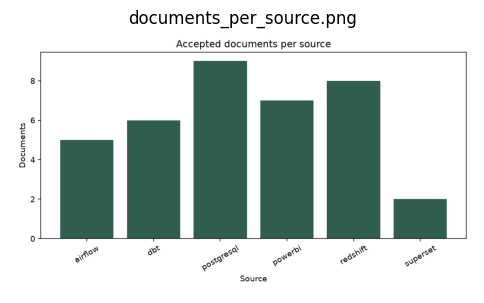

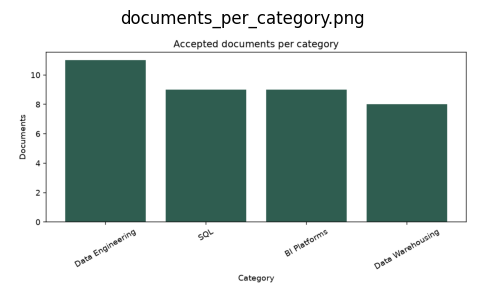

In [ ]:
prep = json.loads(Path("data/processed/stats/preprocessing_stats.json").read_text(encoding="utf-8"))
chunk = json.loads(Path("data/processed/stats/chunking_stats.json").read_text(encoding="utf-8"))

print("input / accepted / rejected:", prep.get("total_input_documents"), prep.get("accepted_documents"), prep.get("rejected_documents"))
print("duplicates:", prep.get("duplicate_count"), "empty:", prep.get("empty_document_count"))
print("total characters:", prep.get("total_characters"))
print("Chunk documents:", chunk.get("documents_chunked"), "→ chunks:", chunk.get("final_chunk_count"))
print("Chunks per source:", json.dumps(chunk.get("chunks_per_source"), indent=2))
print("Chunks per category:", json.dumps(chunk.get("chunks_per_category"), indent=2))

fig_dir = Path("data/processed/stats/figures")
for name in ("documents_per_source.png", "documents_per_category.png"):
    p = fig_dir / name
    if p.exists():
        img = plt.imread(p)
        plt.figure(figsize=(6, 3.5))
        plt.imshow(img)
        plt.axis("off")
        plt.title(name)
        plt.show()


## Model architecture (RAG + LoRA)

The bot is not a single fine-tuned blob. At query time:

User message → normalise → out-of-domain keyword check → embed with `all-MiniLM-L6-v2` → FAISS top-k chunks → prompt (system rules + context + question) → `Qwen2.5-1.5B-Instruct` with optional LoRA adapter → answer + source URLs.

Rejected alternatives (feasibility, not fake win-rates): Gemma-2-2B (gated access), Phi-3.5-mini (heavier), Mistral-7B (tight on T4 with long RAG context). RAG is the factual pathway; LoRA mainly adapts style and domain phrasing.


## 5. Confirm the locked Hugging Face model


In [ ]:
print("Locked generator: Qwen/Qwen2.5-1.5B-Instruct")
print("PEFT method executed: LoRA-fp16 (QLoRA intended when bitsandbytes CUDA wheels exist)")
print("Adapter dir:", Path("experiments/results/adapters/colab_t4_qlora_v1/adapter").exists())
cfg = Path("experiments/results/adapters/colab_t4_qlora_v1/adapter/adapter_config.json")
if cfg.exists():
    ac = json.loads(cfg.read_text(encoding="utf-8"))
    print("peft_type:", ac.get("peft_type"), "r:", ac.get("r"), "lora_alpha:", ac.get("lora_alpha"))
    print("base_model_name_or_path:", ac.get("base_model_name_or_path"))


Locked generator: Qwen/Qwen2.5-1.5B-Instruct
PEFT method executed: LoRA-fp16 (QLoRA intended when bitsandbytes CUDA wheels exist)
Adapter dir: True
peft_type: LORA r: 16 lora_alpha: 32
base_model_name_or_path: Qwen/Qwen2.5-1.5B-Instruct


## Training strategy

- PEFT LoRA (r=16, α=32) on the instruct checkpoint; adapter stored separately from base weights  
- Colab Tesla T4; fp16; 3 epochs with validation loss monitored  
- Small batch + accumulation as configured in `config/model.yaml`  
- Do not default to 25 epochs; stop from validation behaviour  
- Metrics are read from `training_summary.json` only


## 6. Fine-tuning artefacts (executed Colab T4 run)


status: completed
method: LoRA-fp16 | GPU: Tesla T4
train/val: 600 / 67
epochs configured: 3.0
wall clock (s): 977.28
peak GPU GiB: 4.558
train loss (Trainer): 0.8250872230529785
best eval loss: 0.5950806736946106
eval loss by epoch: [1.0101398229599, 0.67005854845047, 0.5950806736946106]


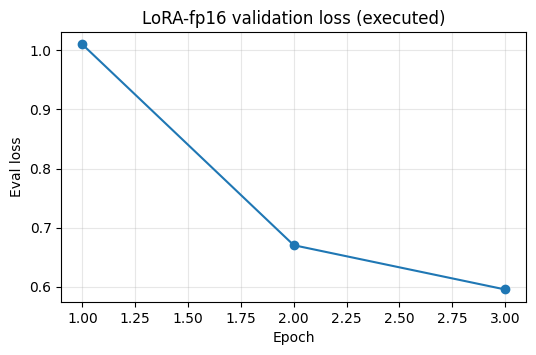

Saved figure: experiments/results/tables/figures/fig_eval_loss_epochs.png


In [ ]:
summary_path = Path("experiments/results/adapters/colab_t4_qlora_v1/training_summary.json")
summary = json.loads(summary_path.read_text(encoding="utf-8"))
metrics = summary.get("metrics_from_trainer") or {}
print("status:", summary.get("status"))
print("method:", summary.get("method"), "| GPU:", summary.get("gpu_name"))
print("train/val:", summary.get("train_examples"), "/", summary.get("validation_examples"))
print("epochs configured:", summary.get("num_epochs_configured"))
print("wall clock (s):", summary.get("wall_clock_seconds"))
print("peak GPU GiB:", summary.get("max_memory_allocated_gb"))
print("train loss (Trainer):", summary.get("train_loss"))
print("best eval loss:", metrics.get("best_eval_loss"))
print("eval loss by epoch:", metrics.get("eval_loss_by_epoch"))

losses = metrics.get("eval_loss_by_epoch") or []
if losses:
    plt.figure(figsize=(6, 3.5))
    plt.plot(range(1, len(losses) + 1), losses, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Eval loss")
    plt.title("LoRA-fp16 validation loss (executed)")
    plt.grid(True, alpha=0.3)
    plt.show()

fig_eval = Path("experiments/results/tables/figures/fig_eval_loss_epochs.png")
if fig_eval.exists():
    print("Saved figure:", fig_eval)


## 7. Vector index for the bot

FAISS `IndexFlatIP` over 384-d MiniLM embeddings. The index file is often omitted from git; rebuild if missing (CPU, a few minutes).


In [ ]:
vs_dir = Path("knowledge_base/vector_store")
index_path = vs_dir / "faiss.index"
print("chunks jsonl:", Path("knowledge_base/chunks/chunks.jsonl").exists())
print("faiss.index:", index_path.exists())
if not index_path.exists():
    print("Building vector store (one-time)...")
    import subprocess
    subprocess.check_call([sys.executable, "scripts/build_vector_store.py"])
print("index now:", index_path.exists())
vs_stats = Path("data/processed/stats/vector_store_stats.json")
if vs_stats.exists():
    vs = json.loads(vs_stats.read_text(encoding="utf-8"))
    print("chunks indexed:", vs.get("chunks_indexed"), "dim:", vs.get("embedding_dim"))
    print("smoke query:", vs.get("smoke_query"))


chunks jsonl: True
faiss.index: True
index now: True
chunks indexed: 281 dim: 384
smoke query: What is a DISTKEY in Amazon Redshift?


## 8. Bot design — query handling (live in this notebook)

`BaselineRAGChatbot.ask()`: empty check → OOD refusal → retrieve → generate.

This cell runs **retrieve-only** plus the OOD rule so the notebook works on CPU. Set `RUN_LLM_DEMO = True` on a T4 runtime to generate a full answer (first load of Qwen 1.5B takes several minutes).


In [ ]:
from src.generation.rag import BaselineRAGChatbot
from src.generation.domain import is_out_of_domain

bot = BaselineRAGChatbot(use_rag=True)

industry_questions = [
    "What is the difference between DISTKEY and SORTKEY?",
    "Why is my LEFT JOIN creating duplicate rows?",
    "What is a dbt incremental model?",
]
ood_question = "What medication should I take for chest pain?"

print("=== Out-of-domain rule ===")
print(ood_question, "→", is_out_of_domain(ood_question))
ood_result = bot.ask(ood_question)
print("mode:", ood_result.get("mode"))
print(ood_result.get("answer")[:400], "...\n")

print("=== Retrieve-only (industry) ===")
for q in industry_questions:
    print("\nQ:", q)
    hits = bot.retrieve(q)
    for h in hits[:3]:
        meta = h.get("metadata") or {}
        print(f"  [{h.get('rank')}] {float(h.get('score', 0)):.3f}  {meta.get('title')} | {meta.get('url')}")


=== Out-of-domain rule ===
What medication should I take for chest pain? → (False, None)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

mode: rag
I'm sorry, but I cannot provide medical advice. Chest pain can be a symptom of various serious conditions, including heart attacks, and should always be evaluated by a healthcare professional. Please consult with a doctor or seek emergency care if you are experiencing chest pain. ...

=== Retrieve-only (industry) ===

Q: What is the difference between DISTKEY and SORTKEY?
  [1] 0.580  CREATE TABLE - Amazon Redshift | https://docs.aws.amazon.com/redshift/latest/dg/r_CREATE_TABLE_NEW.html
  [2] 0.536  CREATE TABLE - Amazon Redshift | https://docs.aws.amazon.com/redshift/latest/dg/r_CREATE_TABLE_NEW.html
  [3] 0.474  CREATE TABLE - Amazon Redshift | https://docs.aws.amazon.com/redshift/latest/dg/r_CREATE_TABLE_NEW.html

Q: Why is my LEFT JOIN creating duplicate rows?
  [1] 0.442  PostgreSQL: Documentation: 18: 7.2. Table Expressions | https://www.postgresql.org/docs/current/queries-table-expressions.html
  [2] 0.430  PostgreSQL: Documentation: 18: SELECT | https://www.postgresql

In [ ]:
# Optional: full LLM answer on Colab T4 (fp16). Leave False for a fast CPU review.
RUN_LLM_DEMO = False

if RUN_LLM_DEMO:
    from src.utils.config import load_yaml
    from src.model.adapter import resolve_lora_adapter_path

    model_cfg = load_yaml("./config/model.yaml")
    adapter = resolve_lora_adapter_path(None)
    llm_bot = BaselineRAGChatbot(
        rag_config=load_yaml("./config/rag.yaml"),
        model_config=model_cfg,
        adapter_path=str(adapter) if adapter else None,
        use_rag=True,
    )
    demo_q = "What is the difference between DISTKEY and SORTKEY?"
    out = llm_bot.ask(demo_q)
    print("mode:", out.get("mode"), "latency_ms:", round(out.get("latency_ms") or 0, 1))
    print(out.get("answer"))
    print("sources:")
    for s in out.get("sources") or []:
        print("-", s.get("url"))
else:
    print("RUN_LLM_DEMO is False. Use Streamlit for the graded live demo: python scripts/run_app.py")


RUN_LLM_DEMO is False. Use Streamlit for the graded live demo: python scripts/run_app.py


## 9. Evaluation on held-out Dataset C

Automatic lexical proxies (not human 1–5 grades). Canonical tables: `experiments/results/tables/results.md`.


# DataPilot AI — experiment results

Numbers below come only from executed runs. LLM system comparison
cells stay `[To be populated after experiment]` until exp_01 / exp_02 GPU runs finish.

## Table 1 - Fine-tuning (executed, Colab T4)

| Field | Value |
|-------|-------|
| Run | `colab_t4_qlora_v1` |
| Model | `Qwen/Qwen2.5-1.5B-Instruct` |
| Method | LoRA-fp16 |
| GPU | Tesla T4 |
| Train / val examples | 600 / 67 |
| Epochs configured | 3.0 |
| Wall clock (s) | 977.3 |
| Peak GPU memory (GiB) | 4.558 |
| Train loss (Trainer) | 0.8251 |
| Best eval loss | 0.5951 |
| Eval loss by epoch | [1.0101398229599, 0.67005854845047, 0.5950806736946106] |

## Table 2 - Retrieval on Dataset C (executed, no LLM)

Dataset: 100 held-out questions. Metric: mean retrieval-relevance proxy on **in-domain** items.

| top-k | In-domain n | Mean retrieval relevance | Zero-coverage n | Median retrieve latency (ms) |
|------:|------------:|-------------------------:|----------------:|-----------------------

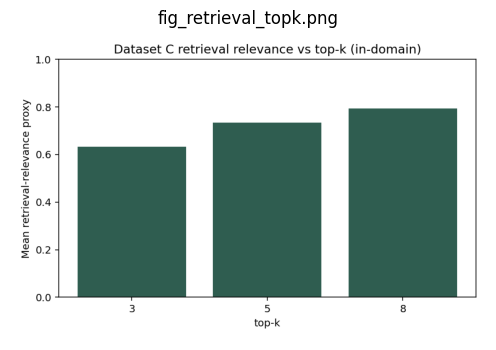

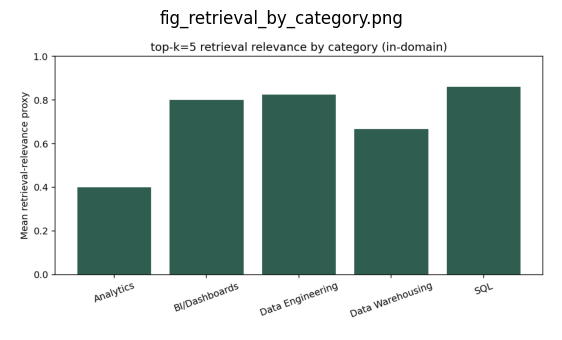

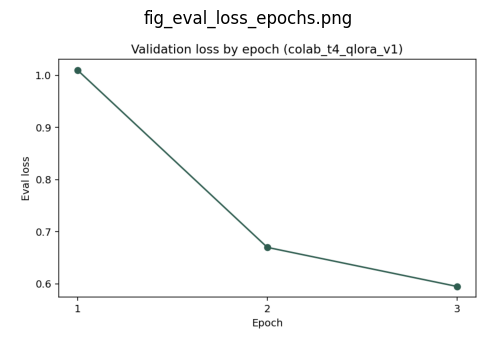

In [ ]:
print(Path("experiments/results/tables/results.md").read_text(encoding="utf-8")[:4000])

fig_dir = Path("experiments/results/tables/figures")
for name in (
    "fig_retrieval_topk.png",
    "fig_retrieval_by_category.png",
    "fig_eval_loss_epochs.png",
):
    p = fig_dir / name
    if p.exists():
        img = plt.imread(p)
        plt.figure(figsize=(7, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(name)
        plt.show()


## 10. Application path — Streamlit LLM bot

The graded demonstration is the **live Streamlit chat**, not this notebook cell. From the project root (local GPU or Colab with a tunnel):

```bash
python scripts/run_app.py
# or: streamlit run app/streamlit_app.py
```

Sidebar modes: Fine-tuned + RAG (System C) · RAG only (System B) · Retrieve only (CPU, no 1.5B download).

The explanation video must show you typing industry questions and the bot answering. Failure to interact with the bot live is grounds for rejection per the capstone brief.


## 11. Next steps

- Companion notebooks: `01_data_collection.ipynb` · `02_data_preprocessing.ipynb` · `03_eda.ipynb` · `04_qlora_finetune.ipynb` (T4) · `05_experiments.ipynb` (T4) · `06_evaluation.ipynb`
- Train CLI: `python scripts/train_qlora.py --no-4bit` on Colab T4
- Bot: `python scripts/run_app.py`
- Adapter: `experiments/results/adapters/colab_t4_qlora_v1/adapter`


## Results analysis & error discussion

### What was tested
- Retrieval relevance on Dataset C without the LLM (top-k 3/5/8)  
- System A (base LLM) vs System B (RAG) vs System C (LoRA + RAG) with point coverage, token F1, ROUGE-L, and latency  

### Interpretation
RAG raised expected-answer-point coverage versus the same Qwen checkpoint without retrieval (0.470 → 0.510) at higher latency. LoRA + RAG produced shorter, more instruction-like answers: higher token F1 (0.333) and ROUGE-L (0.282) but lower point coverage (0.430). Analytics retrieval is the weakest category (0.400 at k=5) because the HTML inventory barely covers KPI topics such as churn and funnels.

### Takeaway for the capstone bot
Industry usefulness comes first from **clean, relevant documentation + retrieval**, then from **LoRA style adaptation**. The live demo should use questions the corpus actually contains (Redshift keys, SQL joins, Airflow, dbt, Power BI), and one out-of-domain refusal.


##Conclusion & Learnings

### Conclusion

DataPilot AI demonstrates the feasibility of building a lightweight,
domain-specific conversational copilot for Business Intelligence and Data
Engineering using an open-source language model, Retrieval-Augmented
Generation (RAG), and parameter-efficient fine-tuning.

The experiments show that retrieval provides useful improvements in
documentation-grounded answer coverage, while LoRA fine-tuning produces
substantial improvements in reference-overlap metrics and response latency.

However, the results also show that fine-tuning does not improve every
evaluation measure. The reduction in point coverage after LoRA indicates
that domain adaptation alone cannot guarantee broader coverage of the
expected answer content.

Overall, the project demonstrates that combining a small language model
with a curated technical knowledge base can provide a practical,
traceable, and resource-efficient approach to domain-specific question
answering.

### Key Learnings

1. **RAG improves grounding**
   
   Providing relevant documentation helps the model cover more of the
   expected answer content compared with the base model.

2. **Knowledge quality matters**
   
   Retrieval performance varied across domains. SQL and Data Engineering
   showed stronger retrieval performance, while Analytics was weaker,
   highlighting the importance of corpus coverage and document quality.

3. **Fine-tuning and RAG solve different problems**
   
   RAG provides external knowledge at inference time, while LoRA adapts
   the model's behaviour using domain-specific examples. Combining them
   does not guarantee improvement across every metric.

4. **Evaluation metrics can disagree**
   
   Point coverage, Token F1, and ROUGE-L measure different aspects of
   generated responses. A model can become more similar to reference
   answers without covering more expected answer points.

5. **Small models can be practical**
   
   Qwen2.5-1.5B enabled experimentation within the available Tesla T4
   compute environment, demonstrating a resource-efficient alternative
   to larger proprietary models for this use case.

6. **Reproducibility requires documenting implementation constraints**
   
   The planned 4-bit QLoRA approach could not be executed because of the
   available GPU environment and `bitsandbytes` compatibility. The final
   experiment therefore used LoRA with fp16, and this distinction is
   explicitly documented.

7. **The current system has clear boundaries**
   
   DataPilot AI is a documentation-grounded question-answering system,
   not an autonomous data engineering agent. It does not execute SQL,
   modify dashboards, or interact with production systems.

### Overall Takeaway

The project shows that a carefully curated knowledge base combined with
retrieval and a lightweight language model can provide a practical
foundation for domain-specific BI and Data Engineering assistance.

The results also highlight that improving the knowledge corpus and retrieval
quality may be as important as further model fine-tuning.